In [ ]:

import kagglehub
mri_path = kagglehub.dataset_download('sartajbhuvaji/brain-tumor-classification-mri')

print('Data source import complete.')


Data source import complete.


In [ ]:
mri_path

'/root/.cache/kagglehub/datasets/sartajbhuvaji/brain-tumor-classification-mri/versions/2'

In [ ]:
# Import necessary libraries
import os
import numpy as np
import random
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Set random seed for full reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Ensure TensorFlow deterministic ops
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.config.experimental.enable_op_determinism()

# Disable OpenCV multithreading
cv2.setNumThreads(0)

# Clear TensorFlow session before model definition
tf.keras.backend.clear_session()

# Define constants
image_size = 150
labels = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
dataset_path = "/root/.cache/kagglehub/datasets/sartajbhuvaji/brain-tumor-classification-mri/versions/2"

# Load and preprocess the data
X_train, Y_train = [], []

# Function to load images in a reproducible way
def load_images(folder_path, label_index):
    images = []
    filenames = sorted(os.listdir(folder_path))  # Sort to ensure consistent order
    for img_file in filenames:
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (image_size, image_size))
        images.append(img)
    return images, [label_index] * len(images)

# Load training images
for idx, label in enumerate(labels):
    train_path = os.path.join(dataset_path, "Training", label)
    imgs, labels_list = load_images(train_path, idx)
    X_train.extend(imgs)
    Y_train.extend(labels_list)

# Load testing images
for idx, label in enumerate(labels):
    test_path = os.path.join(dataset_path, "Testing", label)
    imgs, labels_list = load_images(test_path, idx)
    X_train.extend(imgs)
    Y_train.extend(labels_list)

# Convert lists to numpy arrays
X_train = np.array(X_train, dtype=np.float32)
Y_train = np.array(Y_train, dtype=np.int32)

# Shuffle dataset before splitting
X_train, Y_train = shuffle(X_train, Y_train, random_state=SEED)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_train, Y_train, test_size=0.1, random_state=SEED, shuffle=False)

# Flatten images for fully connected neural network
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes=4)
y_test = to_categorical(y_test, num_classes=4)



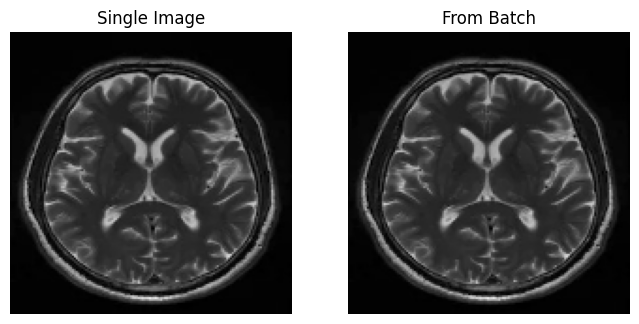

In [ ]:
# Check reproducibility by selecting an index
my_index = 15
input_img_1_flat = X_train[my_index]
reshaped_image = input_img_1_flat.reshape(image_size, image_size, 3)

# Display images for verification
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_train[my_index].reshape(image_size, image_size, 3).astype('uint8'))
axes[0].set_title("Single Image")
axes[0].axis("off")

axes[1].imshow(X_train[my_index:my_index+1][0].reshape(image_size, image_size, 3).astype('uint8'))
axes[1].set_title("From Batch")
axes[1].axis("off")

plt.show()



In [ ]:
# Build a fully connected neural network model
model = Sequential([
    Dense(512, activation='relu', input_shape=(image_size * image_size * 3,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation='softmax')
])

model.summary()




/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │      34,560,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 4)                   │              68 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,735,668 (132.51 MB)

 Trainable params: 34,735,668 (132.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=20, validation_split=0.1, batch_size=32)

In [ ]:
import pandas as pd

def find_mispredicted_images(model, X_train, y_train, labels):
    """
    Finds misclassified images in the training set.

    Parameters:
        model: Trained Keras model
        X_train: Training images (flattened numpy array)
        y_train: True labels (one-hot encoded numpy array)
        labels: List of class labels

    Returns:
        DataFrame with misclassified indices and their true vs predicted labels.
    """

    # Get model predictions
    y_pred_probs = model.predict(X_train)  # Probabilities
    y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class index
    y_true = np.argmax(y_train, axis=1)  # True labels (one-hot to index)

    # Identify misclassified indices
    misclassified_indices = np.where(y_pred != y_true)[0]

    # Create a results table
    results_df = pd.DataFrame({
        "Index": misclassified_indices,
        "True Label": [labels[y] for y in y_true[misclassified_indices]],
        "Predicted Label": [labels[y] for y in y_pred[misclassified_indices]],
        "Correct?": ["❌ Wrong" if y_pred[i] != y_true[i] else "✅ Correct" for i in misclassified_indices]
    })

    return results_df

# Example usage
misclassified_df = find_mispredicted_images(model, X_train, y_train, labels)

# Display misclassified samples
print(misclassified_df)

# Get the index of the first misclassified image
if not misclassified_df.empty:
    first_wrong_index = misclassified_df.iloc[0]["Index"]
    print(f"First misclassified image index: {first_wrong_index}")


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
     Index        True Label Predicted Label Correct?
0        0  meningioma_tumor    glioma_tumor  ❌ Wrong
1        5  meningioma_tumor    glioma_tumor  ❌ Wrong
2       15          no_tumor    glioma_tumor  ❌ Wrong
3       20  meningioma_tumor    glioma_tumor  ❌ Wrong
4       26  meningioma_tumor    glioma_tumor  ❌ Wrong
..     ...               ...             ...      ...
492   2923          no_tumor    glioma_tumor  ❌ Wrong
493   2927  meningioma_tumor    glioma_tumor  ❌ Wrong
494   2932  meningioma_tumor        no_tumor  ❌ Wrong
495   2934  meningioma_tumor    glioma_tumor  ❌ Wrong
496   2935      glioma_tumor        no_tumor  ❌ Wrong

[497 rows x 4 columns]
First misclassified image index: 0


In [ ]:
misclassified_df.head(20)

,Index,True Label,Predicted Label,Correct?
0,0,meningioma_tumor,glioma_tumor,❌ Wrong
1,5,meningioma_tumor,glioma_tumor,❌ Wrong
2,15,no_tumor,glioma_tumor,❌ Wrong
3,20,meningioma_tumor,glioma_tumor,❌ Wrong
4,26,meningioma_tumor,glioma_tumor,❌ Wrong
5,32,meningioma_tumor,glioma_tumor,❌ Wrong
6,40,no_tumor,glioma_tumor,❌ Wrong
7,45,meningioma_tumor,glioma_tumor,❌ Wrong
8,46,no_tumor,glioma_tumor,❌ Wrong
9,47,meningioma_tumor,glioma_tumor,❌ Wrong


In [ ]:
import os
import json
import numpy as np
import tensorflow as tf

def save_layer_details_to_json(model, X_data, output_folder="nn_json_details"):
    os.makedirs(output_folder, exist_ok=True)

    inputs_data = {}
    outputs_data = {}
    weights_data = {}

    for i, layer in enumerate(model.layers):
        layer_name = f"Layer_{i}_{layer.name}"
        print(f"Processing {layer_name}...")

        # Get layer outputs
        intermediate_model = tf.keras.Model(inputs=model.inputs, outputs=layer.output)
        layer_output = intermediate_model.predict(X_data, batch_size=32)

        # Store layer inputs (assuming feed-forward model where inputs are X_data)
        layer_inputs = X_data.tolist() if i == 0 else prev_output.tolist()
        inputs_data[layer_name] = {f"Node_{j}": layer_inputs for j in range(layer_output.shape[1])}

        # Store layer outputs
        outputs_data[layer_name] = {f"Node_{j}": layer_output[:, j].tolist() for j in range(layer_output.shape[1])}

        # Store weights
        if len(layer.get_weights()) > 0:
            weights, biases = layer.get_weights()
            weights_data[layer_name] = {
                f"Node_{j}": {
                    "weights": weights[:, j].tolist(),
                    "bias": biases[j].tolist()
                }
                for j in range(weights.shape[1])
            }

        # Update prev_output for the next layer
        prev_output = layer_output

    # Save JSON files
    with open(os.path.join(output_folder, "inputs.json"), "w") as f:
        json.dump(inputs_data, f, indent=4)

    with open(os.path.join(output_folder, "outputs.json"), "w") as f:
        json.dump(outputs_data, f, indent=4)

    with open(os.path.join(output_folder, "weights.json"), "w") as f:
        json.dump(weights_data, f, indent=4)

    print(f"Details saved to {output_folder}")




In [ ]:
save_layer_details_to_json(model, X_train[my_index:my_index+1])

Processing Layer_0_dense...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 67500))
  warnings.warn(msg)


Processing Layer_1_dense_1...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Processing Layer_2_dense_2...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Processing Layer_3_dense_3...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Processing Layer_4_dense_4...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Processing Layer_5_dense_5...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Processing Layer_6_dense_6...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Details saved to nn_json_details


Prediction

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, batch_size=32)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7068 - loss: 3.1551
Test Loss: 2.9626
Test Accuracy: 0.7187


In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test_classes, y_pred_classes))


              precision    recall  f1-score   support

           0       0.50      0.94      0.65        79
           1       0.95      0.39      0.55        96
           2       0.83      0.62      0.71        64
           3       0.92      0.95      0.94        88

    accuracy                           0.72       327
   macro avg       0.80      0.73      0.71       327
weighted avg       0.81      0.72      0.71       327



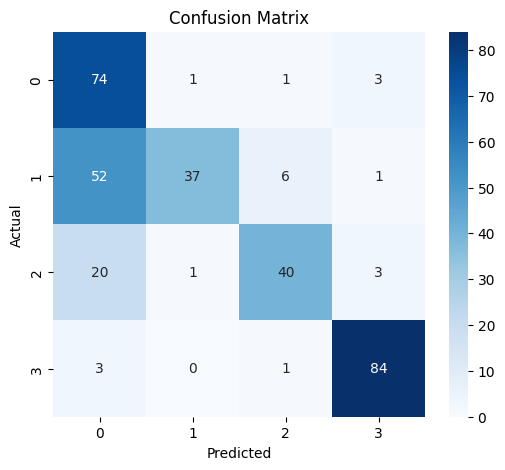

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(4), yticklabels=range(4))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
def decode_prediction(one_hot_array):
    """
    Converts a one-hot encoded prediction into its corresponding class label.

    Parameters:
        one_hot_array (list or numpy array): The one-hot encoded prediction.

    Returns:
        str: The corresponding class label.
    """
    class_index = np.argmax(one_hot_array)  # Get the index of the highest value
    return labels[class_index]  # Map to label


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


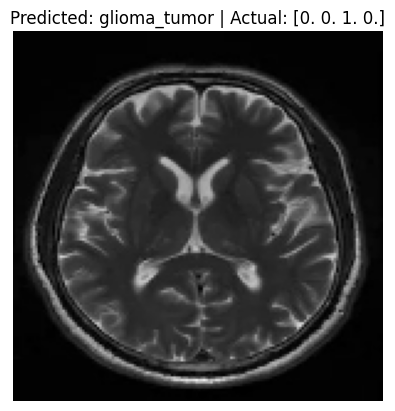

Predicted Class: glioma_tumor
Actual Class: no_tumor


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Select an image
image_index = my_index # Choose any index
single_image = np.expand_dims(X_train[image_index], axis=0)  # Add batch dimension
real_label = y_train[image_index]  # Get the actual class

# Make a prediction
prediction = model.predict(single_image)
predicted_class = labels[np.argmax(prediction)]  # Get predicted class

# Display the image with predicted vs real label
plt.imshow(X_train[image_index].reshape(150, 150, 3).astype('uint8'))  # Adjust shape if needed
plt.axis('off')
plt.title(f"Predicted: {predicted_class} | Actual: {real_label}")
plt.show()

print(f"Predicted Class: {predicted_class}")
print(f"Actual Class: {decode_prediction(real_label)}")


In [ ]:
import json

# Load the JSON file containing node-value pairs
with open('/content/nn_json_details/outputs.json', 'r') as file:
    activations = json.load(file)

# Create a dictionary to hold active nodes
active_nodes = {}

# Iterate through each layer
for layer, nodes in activations.items():
    # Convert all activation values in the layer to float
    activation_values = [float(value[0]) for value in nodes.values()]

    # Compute the mean activation value for the layer
    mean_activation = sum(activation_values) / len(activation_values)

    # Store active nodes that have activation values greater than the mean
    active_nodes[layer] = [
        (node, float(value[0])) for node, value in nodes.items() if float(value[0]) > mean_activation
    ]

# Print out the active nodes
for layer, nodes in active_nodes.items():
    print(f"\nActive nodes in {layer} (Threshold: Mean Activation = {sum([v for _, v in nodes]) / max(1, len(nodes)):.2f}):")
    for node, value in nodes:
        print(f"Node: {node}, Activation: {value}")



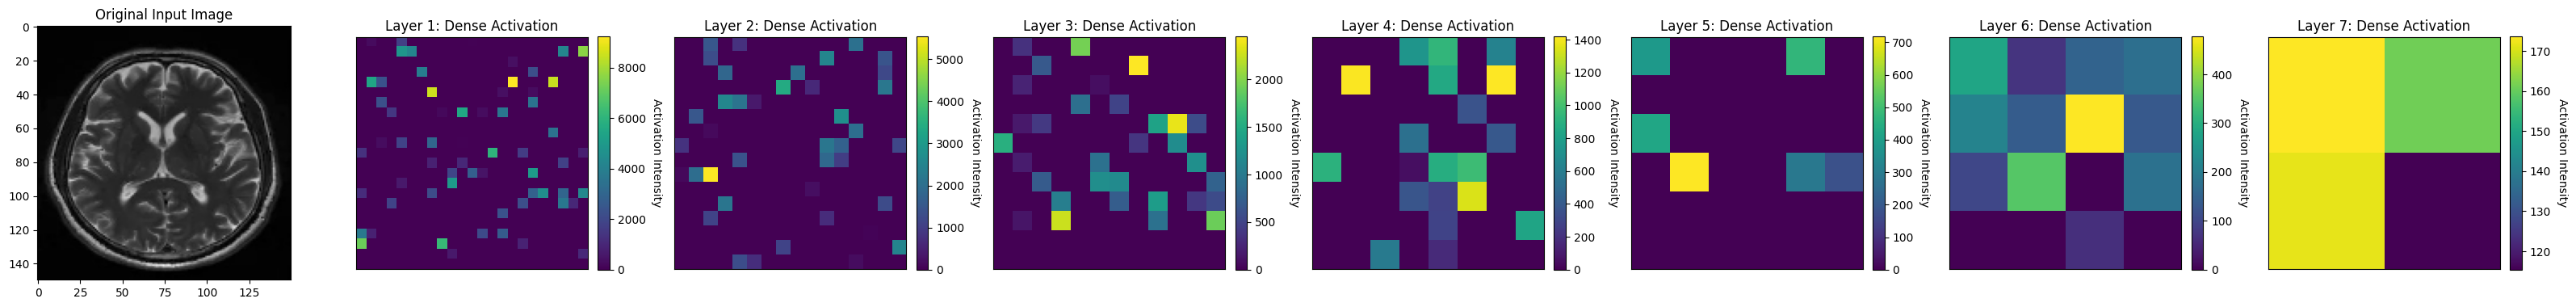

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def visualize_fully_connected_nn(model, input_image, input_shape=(150, 150, 3)):
    """
    Visualize the transformations of the input image through the FullyConnectedNN layers.

    Parameters:
        model: A Keras Sequential model with Dense layers.
        input_image: The input image as a 1D flattened array.
        input_shape: The original shape of the input image (for reshaping).
    """
    reshaped_image = input_image.reshape(input_shape)

    # Store activations starting with the original image
    activations = [reshaped_image]

    for layer in model.layers:
        weights_biases = layer.get_weights()  # Get layer's weights and biases

        if len(weights_biases) == 2:  # Ensure it's a Dense layer
            W, b = weights_biases
            input_image = np.dot(input_image, W) + b

            if "relu" in layer.get_config().get("activation", "").lower():
                input_image = np.maximum(0, input_image)  # Apply ReLU activation

            activations.append(input_image)

    # Determine the number of activations to plot
    num_layers = len(activations)

    # Create subplots
    fig, axes = plt.subplots(1, num_layers, figsize=(num_layers * 4, 4))

    if num_layers == 1:
        axes = [axes]  # Ensure axes is iterable if only one layer exists

    for i, (ax, activation) in enumerate(zip(axes, activations)):
        if i == 0:
            ax.imshow(activation.astype('uint8'))
            ax.set_title("Original Input Image")
        else:
            grid_size = int(np.ceil(np.sqrt(len(activation))))
            heatmap = np.zeros((grid_size, grid_size))
            heatmap.flat[:len(activation)] = activation

            # Display activation map with colorbar
            im = ax.imshow(heatmap, cmap='viridis')
            ax.set_title(f"Layer {i}: Dense Activation")
            ax.set_xticks([])
            ax.set_yticks([])

            # Add colorbar for scale reference
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.set_ylabel('Activation Intensity', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

flattened_image = X_train[my_index]
visualize_fully_connected_nn(model, flattened_image, input_shape=(150, 150, 3))


Modified activations for 'Layer_0_dense' added to 'modified_activations.json'
Processing forward pass from Layer_0_dense to Layer_1_dense_1...
Updated activations for 'Layer_1_dense_1' saved to 'multiplied.json'


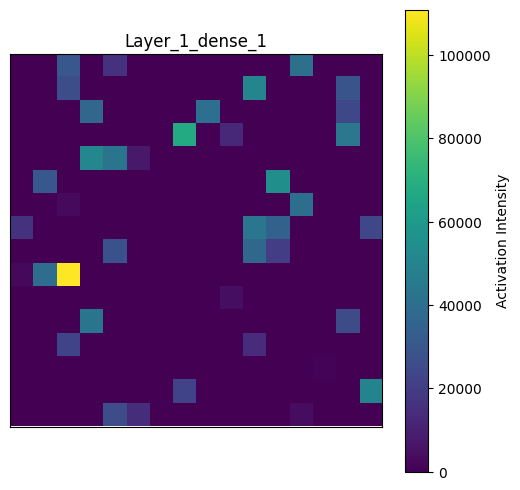

Modified activations for 'Layer_1_dense_1' added to 'modified_activations.json'
Processing forward pass from Layer_1_dense_1 to Layer_2_dense_2...
Updated activations for 'Layer_2_dense_2' saved to 'multiplied.json'


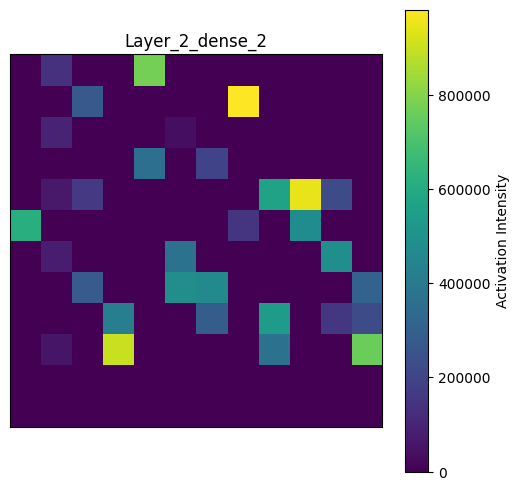

Modified activations for 'Layer_2_dense_2' added to 'modified_activations.json'
Processing forward pass from Layer_2_dense_2 to Layer_3_dense_3...
Updated activations for 'Layer_3_dense_3' saved to 'multiplied.json'


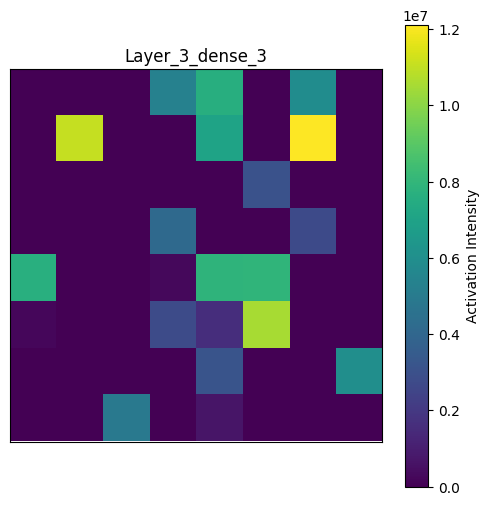

Modified activations for 'Layer_3_dense_3' added to 'modified_activations.json'
Processing forward pass from Layer_3_dense_3 to Layer_4_dense_4...
Updated activations for 'Layer_4_dense_4' saved to 'multiplied.json'


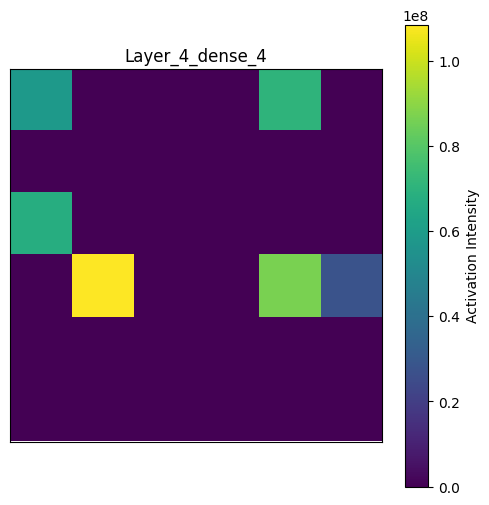

Modified activations for 'Layer_4_dense_4' added to 'modified_activations.json'
Processing forward pass from Layer_4_dense_4 to Layer_5_dense_5...
Updated activations for 'Layer_5_dense_5' saved to 'multiplied.json'


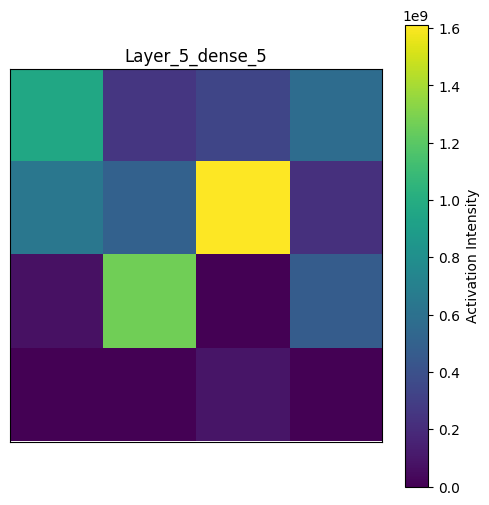

Modified activations for 'Layer_5_dense_5' added to 'modified_activations.json'
Processing forward pass from Layer_5_dense_5 to Layer_6_dense_6...
Updated activations for 'Layer_6_dense_6' saved to 'multiplied.json'


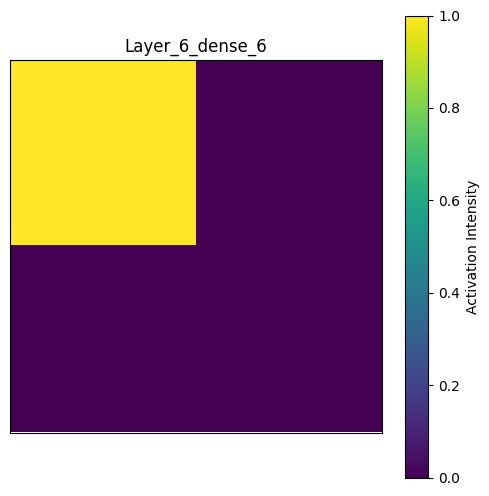

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

def modify_layer_activations(input_file, layer_name_to_modify, output_file="modified_activations.json"):
    """
    Modifies activations for a specified layer by amplifying top 25% activations and suppressing others.
    """
    try:
        with open(input_file, 'r') as file:
            activations = json.load(file)
    except (FileNotFoundError, json.JSONDecodeError):
        print(f"Error: Could not read '{input_file}'. Ensure the file exists and is formatted correctly.")
        return

    # Read or initialize the modified activations file
    try:
        with open(output_file, 'r') as file:
            modified_activations = json.load(file)
    except (FileNotFoundError, json.JSONDecodeError):
        modified_activations = {}

    if layer_name_to_modify in activations:
        nodes = activations[layer_name_to_modify]
        activation_values = np.array([float(value[0]) for value in nodes.values()])

        if len(activation_values) == 0:
            print(f"Warning: No activations found for layer '{layer_name_to_modify}'.")
            return

        threshold = np.percentile(activation_values, 80)
        modified_values = np.where(activation_values >= threshold, activation_values * 20, activation_values * 0.05)

        modified_activations[layer_name_to_modify] = {
            node: [str(modified_values[idx])]
            for idx, (node, value) in enumerate(nodes.items())
        }

        with open(output_file, 'w') as outfile:
            json.dump(modified_activations, outfile, indent=4)

        print(f"Modified activations for '{layer_name_to_modify}' added to '{output_file}'")
    else:
        print(f"Error: Layer '{layer_name_to_modify}' not found in '{input_file}'.")

def stable_softmax(raw_outputs):
    """
    Numerically stable softmax function.
    Subtracts the maximum value from the raw outputs before exponentiation to prevent overflow.
    """
    max_val = np.max(raw_outputs)
    exp_shifted = np.exp(raw_outputs - max_val)
    return exp_shifted / np.sum(exp_shifted)

def forward_pass(modified_layer_name, next_layer_name, weight_file, output_file="multiplied.json", activation_fn="relu"):
    """
    Performs a forward pass using modified activations and applies weights & biases.
    """
    try:
        with open("modified_activations.json", "r") as file:
            modified_activations = json.load(file)
        with open(weight_file, "r") as file:
            weights_data = json.load(file)
    except (FileNotFoundError, json.JSONDecodeError):
        print("Error: Missing or corrupt JSON file.")
        return

    if modified_layer_name in modified_activations and next_layer_name in weights_data:
        print(f"Processing forward pass from {modified_layer_name} to {next_layer_name}...")

        prev_layer_output = np.array([float(value[0]) for value in modified_activations[modified_layer_name].values()])
        weights_for_next_layer = weights_data[next_layer_name]

        raw_outputs = []
        for node_key, params in weights_for_next_layer.items():
            weight_vector = np.array(params['weights'])
            bias_value = float(params['bias'])
            updated_value = np.dot(prev_layer_output, weight_vector) + bias_value
            raw_outputs.append(updated_value)

        # Apply activation function
        if activation_fn == "relu":
            activated_outputs = np.maximum(0, raw_outputs)
        elif activation_fn == "softmax":
            activated_outputs = stable_softmax(raw_outputs)
        else:
            print(f"Error: Unsupported activation function: {activation_fn}")
            return

        new_layer_output = {node_key: [str(val)] for node_key, val in zip(weights_for_next_layer.keys(), activated_outputs)}

        # Save with the correct key name to avoid lookup errors
        with open(output_file, "w") as outfile:
            json.dump({next_layer_name: new_layer_output}, outfile, indent=4)

        print(f"Updated activations for '{next_layer_name}' saved to '{output_file}'")
    else:
        print(f"Error: Layers '{modified_layer_name}' or '{next_layer_name}' not found.")

def visualize_updated_activations(modified_json_file="multiplied.json"):
    """
    Visualizes updated activations.
    """
    try:
        with open(modified_json_file, "r") as file:
            modified_activations = json.load(file)
    except (FileNotFoundError, json.JSONDecodeError):
        print(f"Error: Could not read '{modified_json_file}'.")
        return

    for layer_name, layer_activations in modified_activations.items():
        activation_values = np.array([float(value[0]) for value in layer_activations.values()])
        grid_size = int(np.ceil(np.sqrt(len(activation_values))))
        heatmap = np.zeros((grid_size, grid_size))
        heatmap.flat[:len(activation_values)] = activation_values

        plt.figure(figsize=(6, 6))
        plt.imshow(heatmap, cmap="viridis")
        plt.colorbar(label="Activation Intensity")
        plt.title(layer_name)
        plt.xticks([])
        plt.yticks([])
        plt.show()

# Run layer-by-layer forward pass
layers = [
    ("Layer_0_dense", "Layer_1_dense_1"),
    ("Layer_1_dense_1", "Layer_2_dense_2"),
    ("Layer_2_dense_2", "Layer_3_dense_3"),
    ("Layer_3_dense_3", "Layer_4_dense_4"),
    ("Layer_4_dense_4", "Layer_5_dense_5"),
    ("Layer_5_dense_5", "Layer_6_dense_6")
]

activation_file = "/content/nn_json_details/outputs.json"
modified_file = "modified_activations.json"
output_file = "multiplied.json"

for i, (current_layer, next_layer) in enumerate(layers):
    input_file = activation_file if i == 0 else output_file

    # Modify activations of the current layer
    modify_layer_activations(input_file, current_layer, modified_file)

    # Verify that the layer exists
    with open(modified_file, "r") as f:
        modified_data = json.load(f)

    if current_layer not in modified_data:
        raise ValueError(f"Error: Layer '{current_layer}' not found in {modified_file}. Check modify_layer_activations().")

    # Forward pass
    forward_pass(
        modified_layer_name=current_layer,
        next_layer_name=next_layer,
        weight_file="/content/nn_json_details/weights.json",
        output_file=output_file,
        activation_fn="softmax" if i == len(layers) - 1 else "relu"
    )

    # Verify that the next layer has been updated
    with open(output_file, "r") as f:
        output_data = json.load(f)

    if next_layer not in output_data:
        raise ValueError(f"Error: Layer '{next_layer}' not found in {output_file}. Check forward_pass().")

    # Visualize new activations
    visualize_updated_activations(output_file)


In [ ]:
def visualize_raw_last_layer(modified_json_file="raw_last_layer_activations.json"):
    """
    Visualizes last layer activations BEFORE applying softmax.
    """
    try:
        with open(modified_json_file, "r") as file:
            modified_activations = json.load(file)
    except (FileNotFoundError, json.JSONDecodeError):
        print(f"Error: Could not read '{modified_json_file}'.")
        return

    for layer_name, layer_activations in modified_activations.items():
        activation_values = np.array([float(value[0]) for value in layer_activations.values()])
        grid_size = int(np.ceil(np.sqrt(len(activation_values))))
        heatmap = np.zeros((grid_size, grid_size))
        heatmap.flat[:len(activation_values)] = activation_values

        plt.figure(figsize=(6, 6))
        plt.imshow(heatmap, cmap="inferno")
        plt.colorbar(label="Raw Activation Intensity")
        plt.title(f"Raw Activations - {layer_name} (Before Softmax)")
        plt.xticks([])
        plt.yticks([])
        plt.show()
